# Explore here

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# load the .env file variables
load_dotenv()

True

In [2]:
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

In [3]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

auth_manager = SpotifyClientCredentials(client_id = client_id, client_secret = client_secret)
spotify = spotipy.Spotify(auth_manager = auth_manager)

In [5]:
GreenDay_id = "7oPftvlwr6VrsViSDV7fJY"
GreenDay_Top10 = spotify.artist_top_tracks(GreenDay_id)

In [11]:
tracks = GreenDay_Top10["tracks"]
data = []

for song in tracks:
    data.append({
        "name": song["name"],
        "popularity": song["popularity"],
        "duration_min": song["duration_ms"] / 60000
    })

In [12]:
GD = pd.DataFrame(data)
GD

,name,popularity,duration_min
0,Boulevard of Broken Dreams,80,4.348933
1,Basket Case,82,3.025550
2,American Idiot,82,2.939100
3,Wake Me up When September Ends,81,4.760883
4,Brain Stew,80,3.216667
5,Good Riddance (Time of Your Life),79,2.557767
6,Holiday,75,3.880433
7,When I Come Around,78,2.966667
8,21 Guns,76,5.351550
9,Last Night on Earth,76,3.942217


In [13]:
GD_sorted = GD.sort_values("popularity", ascending=True)
GD_sorted.head(3)

,name,popularity,duration_min
6,Holiday,75,3.880433
8,21 Guns,76,5.351550
9,Last Night on Earth,76,3.942217


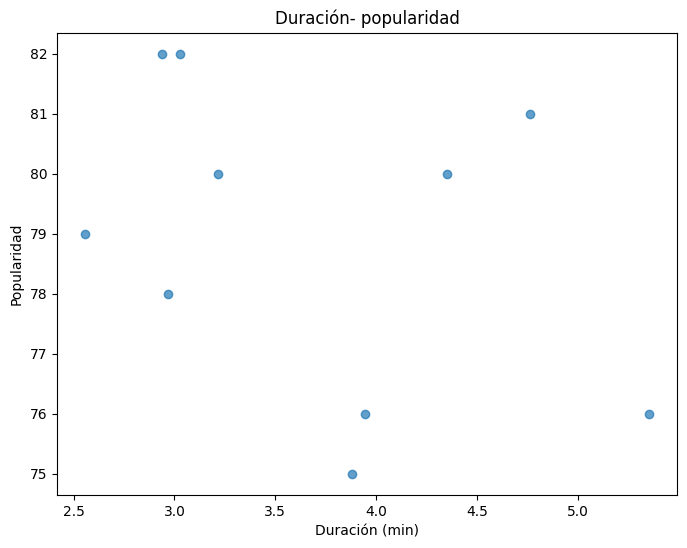

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(GD["duration_min"], GD["popularity"], alpha=0.7)

plt.xlabel("Duración (min)")
plt.ylabel("Popularidad")
plt.title("Duración- popularidad")

plt.show()


¿Tiene relación la duración con la popularidad? ¿Podríamos decir que una canción que dure poco tiempo puede ser más popular que otra que dure más?

-A nivel personal considero que no guarda ninguna relación una cosa con la otra, con el gráfico lo confirmo porque no se ven agrupaciones evidentes por minuto/popularidad, quitando dos que están cerca a la altura de 82 puntos de popularidad, 'Basket Case' y 'American Idiot'. Ambas canciones son cortas pero bastante comerciales, de ahí su popularidad.

He creado un gráfico extra como el anterior pero con todas las canciones de Green Day para poder responder mejor la pregunta, ya que con una muestra de 10 canciones no creo que deban trazarse conclusiones.

In [25]:
albums = spotify.artist_albums(
    GreenDay_id,
    album_type="album,single,appears_on",
    limit=50
)

album_ids = list({album["id"] for album in albums["items"]})

all_tracks = []


for album_id in album_ids:
    offset = 0
    
    while True:
        tracks = spotify.album_tracks(album_id, limit=50, offset=offset)
        
        if not tracks["items"]:
            break
        
        for t in tracks["items"]:
            all_tracks.append(t["id"])
        
        offset += 50

full_track_info = []


for i in range(0, len(all_tracks), 50):
    batch = all_tracks[i:i+50]
    results = spotify.tracks(batch)
    
    for track in results["tracks"]:
        if track is not None:
            full_track_info.append({
                "name": track["name"],
                "popularity": track["popularity"],
                "duration_min": track["duration_ms"] / 60000
            })



In [28]:
GD_all = pd.DataFrame(full_track_info)
GD_all= GD_all.drop_duplicates(subset="name") 

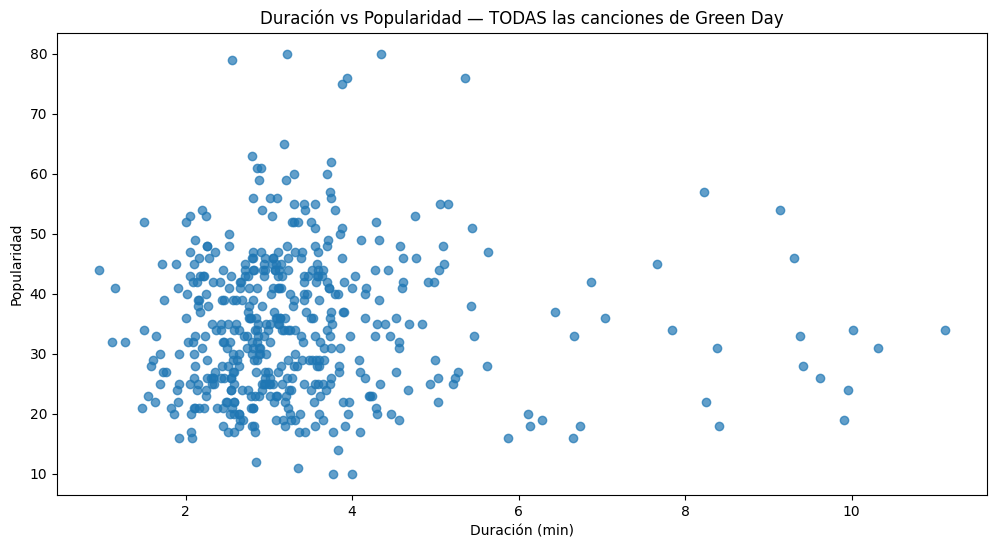

In [34]:
plt.figure(figsize=(12,6))
plt.scatter(GD_all["duration_min"], GD_all["popularity"], alpha=0.7)

plt.xlabel("Duración (min)")
plt.ylabel("Popularidad")
plt.title("Duración vs Popularidad — TODAS las canciones de Green Day")

plt.show()


Ahora sí, con un grupo muestral mucho mayor (>400), podemos ver mejor la relación. En el caso de Green Day, se concentran la mayoría de canciones entre los minutos 2 y 4, pero la popularidad está entre 20-50 en la zona más concentrada. Las más populares también tienen duraciones parecidas. Las 6 canciones con mayor popularidad están por encima de la nube justamente. Por lo que reitero mi respuesta, bajo mi punto de vista no hay correlación entre ambos factores.